<a href="https://colab.research.google.com/github/ikramkakar/Afghanistan-s-population-growth-percent-over-years-using-a-scatter-plot-in-matplotlib/blob/main/Students_Performance_ML_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

**1- Data preprocessing** -Load Data- The synthetic Dataset was seprately created

In [7]:
data = pd.read_csv("student_performance.csv")

We use data.head() used to display the first few rows of a DataFrame or Series

In [9]:
data.head()

,attendance_percentage,midterm_score,assignment_avg,study_hours_per_week,previous_year_gpa,participation_score,annual_performance
0,82.450712,48.420100,81.354829,16.843367,2.875135,NaN,153.660107
1,NaN,53.796379,56.167520,13.033306,2.542357,5.897629,101.165295
2,84.715328,79.945872,83.044089,15.143724,2.873379,5.363602,111.890457
3,97.845448,77.207405,90.334568,21.392259,3.125979,6.993251,122.378947
4,71.487699,64.581968,76.201524,15.955495,2.829316,6.659631,91.476188


We can see there are some missing values, we need to handle this missing value, but first lets count the missing values

In [10]:
print(data.isnull().sum())

attendance_percentage    15
midterm_score            15
assignment_avg           15
study_hours_per_week     15
previous_year_gpa        15
participation_score      15
annual_performance       15
dtype: int64


The data is synthetic  - We may see some sort of not real outcome but there are missing values and we will use **mean** to replace the missing values as there are numberic values in the dataset- but there are other ways to halding the missing values depends on Data Volume: If I have 1 million rows and only 10 are missing values, deletion is fine. If I only have 100 rows, every data point is precious, and imputation is necessary.
Data Type: Categorical data usually requires Mode Imputation or a "Missing" label, while numerical data allows for Mean/Median or Interpolation(Esttimate missing values that fall between known data points).


In [13]:
data.fillna(data.mean(), inplace=True) # inplace=True "" means missing values filled, and the original data DataFrame would remain unchanged

Split Features and Target




In [15]:
X = data.drop("annual_performance", axis=1) # axis=1 It tells Pandas to look for the label "annual_performance" among the column headers
y = data["annual_performance"]

Train-Test Split- train_test_split can be used with virtually every supervised learning model in scikit-learn- We split the dataset to** test=20% and train=80%**. **random_state=42** By setting a seed (like 42), we ensure that every time we run our code, we get the exact same results. Without it, our data split or model performance would change slightly every single time we hit "run."


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)  # train_test_split can be used with virtually every supervised learning model in scikit-learn

Feature Scaling -
 **StandardScaler()**- It shifts  data so the average is 0 and standard deviation is 1.It stops features with huge numbers (like "Salary") from dominating features with tiny numbers (like "Age").Every column is converted to the same scale, which helps most machine learning models learn much faster and more accurately. it uses The Formula (Z-Score)= **X Original data Point- Means/Standard Deviation**.
For every value in a column, it performs this calculation:


In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**2- Exploratory Data Analysis (EDA)-**
Summary Statistics

In [19]:
print(data.describe())

       attendance_percentage  midterm_score  assignment_avg  \
count             300.000000     300.000000      300.000000   
mean               74.755555      64.765298       71.364022   
std                14.312517      18.619288       14.734847   
min                26.380990      18.961577       29.546700   
25%                65.219511      51.981181       61.777000   
50%                74.755555      64.765298       71.364022   
75%                83.449665      76.631867       80.532556   
max               132.790972     126.577616      109.485731   

       study_hours_per_week  previous_year_gpa  participation_score  \
count            300.000000         300.000000           300.000000   
mean              16.326049           2.862065             7.077659   
std                7.471346           0.586950             1.947201   
min                0.518723           1.245375             1.157299   
25%               12.642137           2.436616             5.792771   
50%   

Looking at statistic summary, the max values suggest we have some errors or outliers:

1.   **attendance_percentage (132.79)**: This is likely an error, as attendance
usually cannot exceed 100%.
2.  **midterm_score (126.57)**: Unless there was a lot of extra credit, this might be an unrealistic score for a standard exam.
3.  **assignment_avg (109.48)**: Similar to the others, this exceeds the typical 100% cap.


We apply a capping strategy to `attendance_percentage`, `midterm_score`, and `assignment_avg` columns, setting values above a logical maximum (100) to that maximum. **Capping Strategy** Any number above 100 becomes 100. Any number below a certain floor (if you set one) becomes that floor. We have other technics like RobustScaler to handle outlier or use Mediam instead of means

To address the outliers identified in the summary statistics, I will cap the values in 'attendance_percentage', 'midterm_score', and 'assignment_avg' columns at 100, as these metrics typically do not exceed 100.



In [22]:
data['attendance_percentage'] = data['attendance_percentage'].apply(lambda x: 100 if x > 100 else x)
data['midterm_score'] = data['midterm_score'].apply(lambda x: 100 if x > 100 else x)
data['assignment_avg'] = data['assignment_avg'].apply(lambda x: 100 if x > 100 else x)

print("Outliers capped for attendance_percentage, midterm_score, and assignment_avg.")

Outliers capped for attendance_percentage, midterm_score, and assignment_avg.


Now that the outliers have been capped, I will print the descriptive statistics of the 'data' DataFrame to verify that the maximum values for 'attendance_percentage', 'midterm_score', and 'assignment_avg' are now 100 or less.



In [23]:
print(data.describe())

       attendance_percentage  midterm_score  assignment_avg  \
count             300.000000     300.000000      300.000000   
mean               74.431220      64.495732       71.188876   
std                13.530927      17.995891       14.340653   
min                26.380990      18.961577       29.546700   
25%                65.219511      51.981181       61.777000   
50%                74.755555      64.765298       71.364022   
75%                83.449665      76.631867       80.532556   
max               100.000000     100.000000      100.000000   

       study_hours_per_week  previous_year_gpa  participation_score  \
count            300.000000         300.000000           300.000000   
mean              16.326049           2.862065             7.077659   
std                7.471346           0.586950             1.947201   
min                0.518723           1.245375             1.157299   
25%               12.642137           2.436616             5.792771   
50%   

## Summary:

Data Analysis:
*   Outlier values in the `attendance_percentage`, `midterm_score`, and `assignment_avg` columns were successfully capped at 100.
*   Following the capping operation, the maximum values for `attendance_percentage`, `midterm_score`, and `assignment_avg` are all now precisely 100.0, as verified by the descriptive statistics.

### Insights
*   The data is now prepared with appropriate upper bounds for these academic metrics, ensuring consistency and preventing skewed analysis from unrealistic values.



Correlation Heatmap

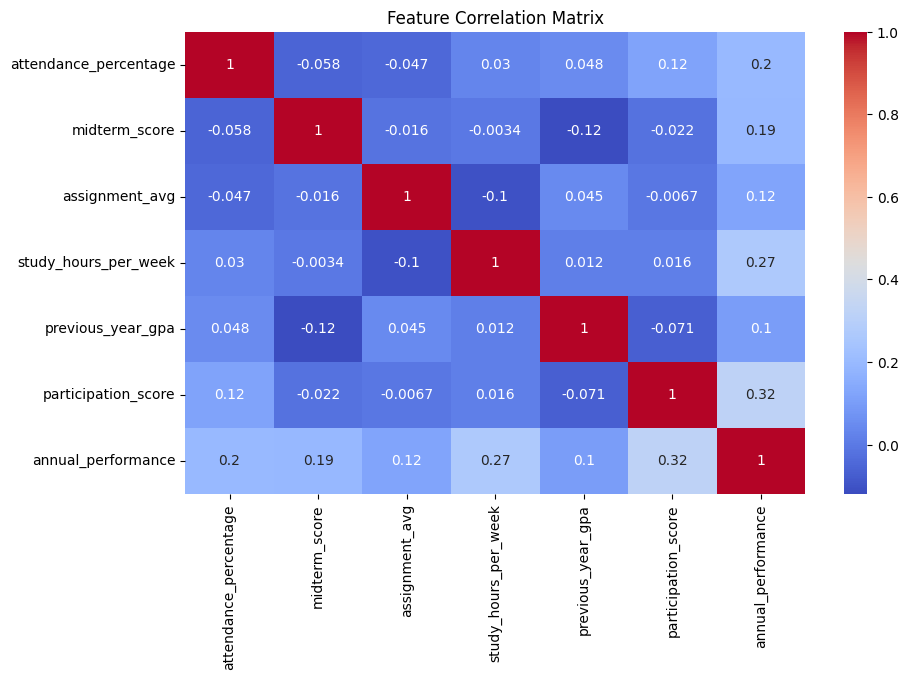

In [28]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

**The feature correlation Matrix**

Feature	Correlation with Annual Performance	Interpretation

1.   participation_score	0.32	Moderate positive (strongest predictor here)
2.   study_hours_per_week	0.27	Moderate positive
3.   attendance_percentage	0.20	Weak moderate positive
4.   midterm_score	0.19	Weak moderate positive
5.   assignment_avg	0.12	Weak positive
6.   previous_year_gpa	0.10	Weak positive


1.**Most important predictors:**

participation_score

study_hours_per_week

attendance_percentage

midterm_score

2.**Less important:**

previous_year_gpa

assignment_avg



**3- Model Design** -Linear Regression

In [25]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

Linear Regression

Simple

Interpretable

Baseline model

In [26]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In a Random Forest, **n_estimators=100** means the model will build 100 individual decision trees to make its prediction

Random Forest

Handles non-linearity

Robust to noise

Handles outliers better

Random Forest does not require scaling.

**4- Model Evaluation**

Linear Regression

In [29]:
print("Linear Regression Results")
print("MSE:", mean_squared_error(y_test, lr_pred))
print("R2:", r2_score(y_test, lr_pred))

Linear Regression Results
MSE: 289.6680741317527
R2: 0.33851942282664393


Random Forest

In [30]:
print("Random Forest Results")
print("MSE:", mean_squared_error(y_test, rf_pred))
print("R2:", r2_score(y_test, rf_pred))

Random Forest Results
MSE: 283.8402080495956
R2: 0.35182782842594673


Random Forest MSE = 283.84

Linear Regression MSE = 289.67

Since lower MSE is better, Random Forest performs slightly better.

Difference:

289.67
−
283.84
=
5.83
289.67−283.84=5.83

R² Score (Explained Variance)

Random Forest R² = 0.3518

Linear Regression R² = 0.3385

R² tells us how much variance in the target variable is explained by the model.

Random Forest explains:

35.18
%
 of variance
35.18% of variance

Linear Regression explains:

33.85
%
 of variance
33.85% of variance

Difference:

0.3518
−
0.3385
=
0.0133
0.3518−0.3385=0.0133

R² (Higher is Better)
Random 	0.3518 - 35%
Linear Regression	0.3385- 33% -

This means 65% of the variance is still unexplained

Model performance is moderate/weak

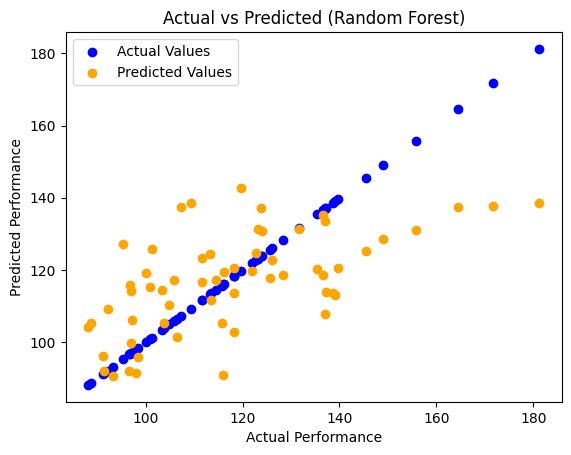

In [34]:
plt.scatter(y_test, y_test, color='blue', label='Actual Values')
plt.scatter(y_test, rf_pred, color='orange', label='Predicted Values')
plt.xlabel("Actual Performance")
plt.ylabel("Predicted Performance")
plt.title("Actual vs Predicted (Random Forest)")
plt.legend()
plt.show()

**5- Prediction on New Students**

In [35]:
new_student = pd.DataFrame({
    "attendance_percentage": [85],
    "midterm_score": [78],
    "assignment_avg": [80],
    "study_hours_per_week": [20],
    "previous_year_gpa": [3.2],
    "participation_score": [8]
})

prediction = rf.predict(new_student)
print("Predicted Annual Performance:", prediction)

Predicted Annual Performance: [135.86192447]
